In [1]:
from pathlib import Path

from adapt_eeg.data_reader import build_metadata, read_sample, merge_data


DATA_DIR = Path("../data/raw/itpc-30event-good")

metadata = build_metadata(DATA_DIR)

In [2]:
# short the metadata by line then participant
metadata = sorted(metadata, key=lambda x: (x.line, x.participant))

In [6]:
from typing import Any

from mne import BaseEpochs
import mne
from pydantic import BaseModel, ConfigDict

from adapt_eeg.data_reader import SampleMetadata


class Sample(SampleMetadata, BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    data: Any


data = []
for sample in metadata:
    print(f"Merging line {sample.line} for participant {sample.participant}...")
    try:
        epochs = mne.read_epochs_eeglab(sample.set_path, verbose="ERROR")
    except Exception as _17:
        raw = mne.io.read_raw_eeglab(sample.set_path, verbose="ERROR")
        data.append(
            Sample(
                **sample.model_dump(),
                data=raw,
            )
        )
        continue

    try:
        merged_epochs, _ = merge_data(
            epochs, min_shift=15, max_shift=40, verbose=False
        )  # type: ignore
        data.append(
            Sample(
                **sample.model_dump(),
                data=merged_epochs,
            )
        )

    except Exception as e:
        print(
            f"Failed to merge line {sample.line} for participant {sample.participant}: {e}"
        )

Merging line 1 for participant 1...
Merging line 1 for participant 2...
Merging line 1 for participant 4...
Merging line 1 for participant 5...
Merging line 1 for participant 6...
Merging line 1 for participant 8...
Merging line 1 for participant 10...
Merging line 1 for participant 11...
Merging line 1 for participant 12...
Merging line 1 for participant 13...
Merging line 1 for participant 15...
Merging line 1 for participant 16...
Merging line 1 for participant 17...
Merging line 1 for participant 18...
Merging line 1 for participant 19...
Merging line 1 for participant 20...
Merging line 1 for participant 21...
Merging line 1 for participant 22...
Merging line 1 for participant 23...
Merging line 1 for participant 24...
Merging line 1 for participant 25...
Merging line 1 for participant 26...
Merging line 1 for participant 27...
Merging line 1 for participant 28...
Merging line 1 for participant 29...
Merging line 1 for participant 30...
Merging line 1 for participant 31...
Merging

In [ ]:
# filter metadata to samples with line 8 
line8 = [sample for sample in metadata if sample.line == 8 and sample.participant == 55]
# read_sample(line8[0])
read_sample(metadata[0])

<EpochsEEGLAB | 26 events (all good), -0.102 – 0.195 s (baseline off), ~307 KiB, data loaded,
 '1/1/1/1': 26>

In [ ]:
import mne


raw = mne.io.read_raw_eeglab(line8[0].set_path)

Reading /home/tu/code-py/adapt-eeg/notebooks/../data/raw/itpc-30event-good/line8/part55v8.fdt


In [ ]:
raw

<RawEEGLAB | part55v8.fdt, 18 x 479 (1.9 s), ~25 KiB, data not loaded>

In [ ]:
data[0].data

<EpochsArray | 1 events (all good), -0.102 – 2.285 s (baseline off), ~111 KiB, data loaded,
 'reconstructed_sequence': 1>

Using matplotlib as 2D backend.


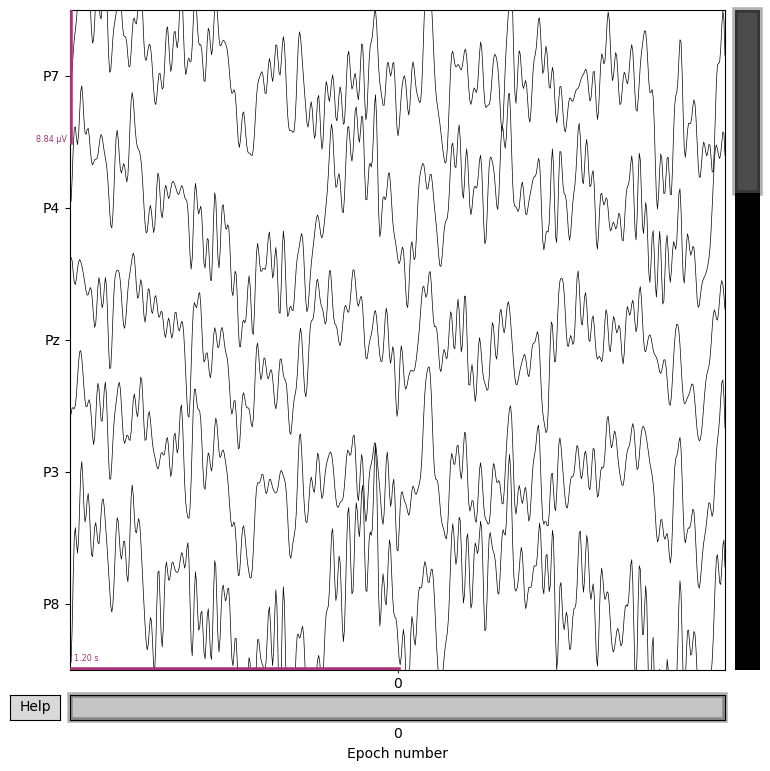

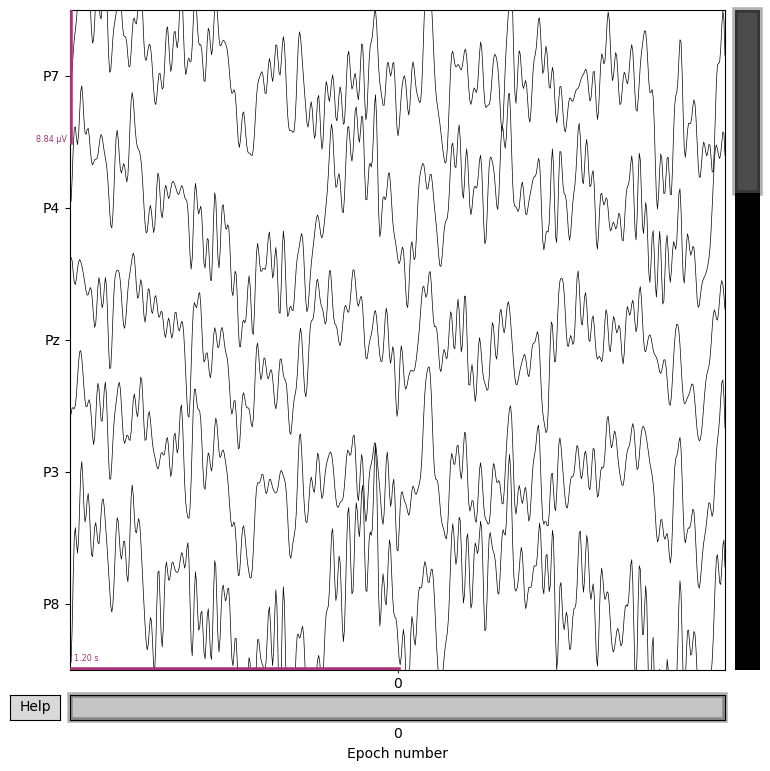

In [ ]:
data[0].data.plot(
    n_epochs=5,
    n_channels=5,
    scalings="auto",
)

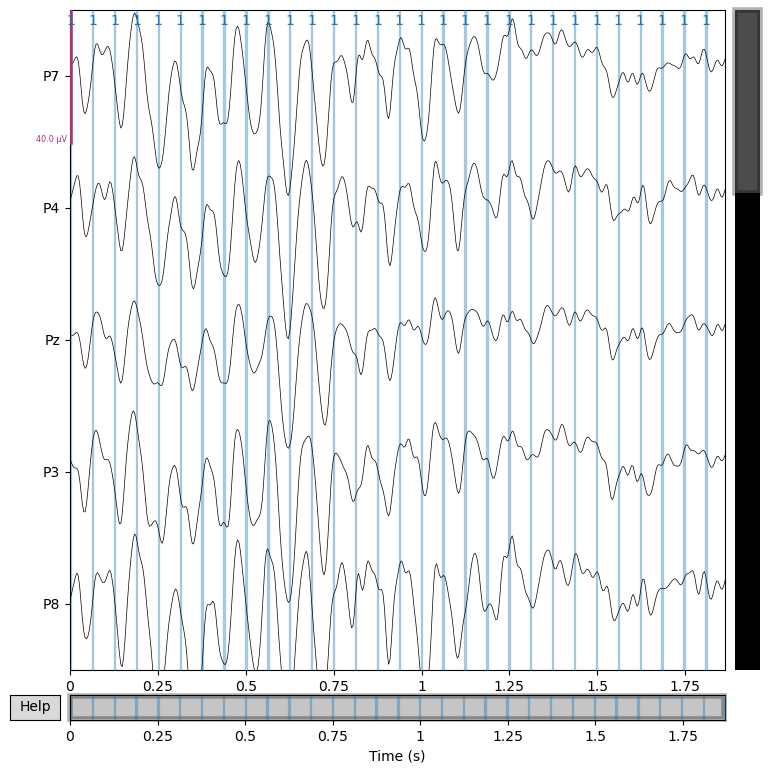

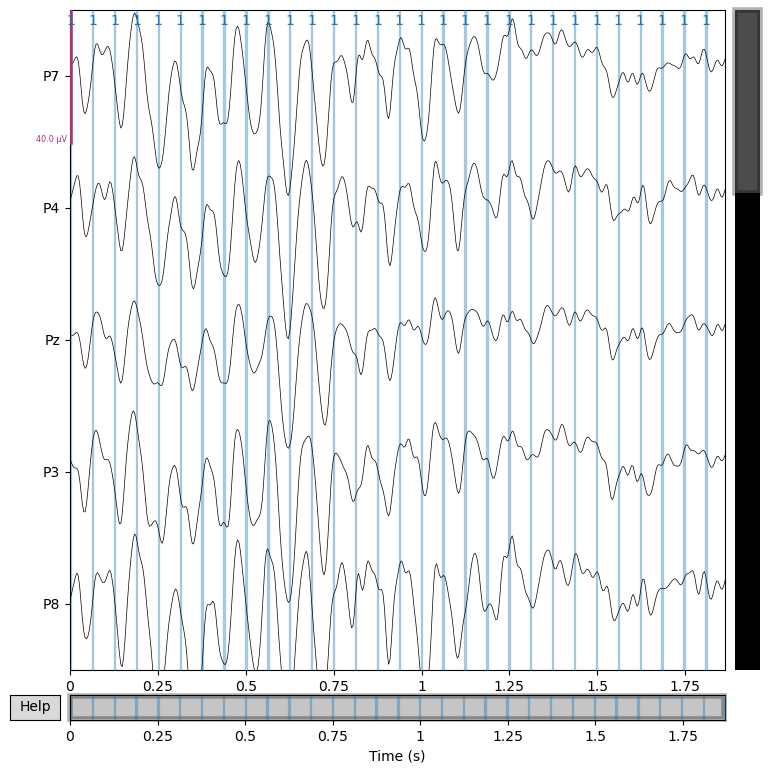

In [ ]:
raw.plot(
    n_channels=5,
)